In [1]:
# Parameters
param1=1

In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, create_data
from utils import cosine_similarity, get_r_2, vector_angle, factorize_matrix
from tqdm import tqdm
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [3]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [4]:
C = Config()

C.sig_h_2 = 1e-5
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.00001
C.L=8
C.print_progress = True
C.length_corridors = [50]
# C.input_size = 100
C.max_move = C.length_corridors[0]//2+1
C.hidden_size = (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs *= 1
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.label_noise = 0
C.B = 1
# C.whiten_data = True
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

Changed G to 0.6139819622039795 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.2969371709914412e-05


100%|██████████| 10000/10000 [00:26<00:00, 377.97it/s]


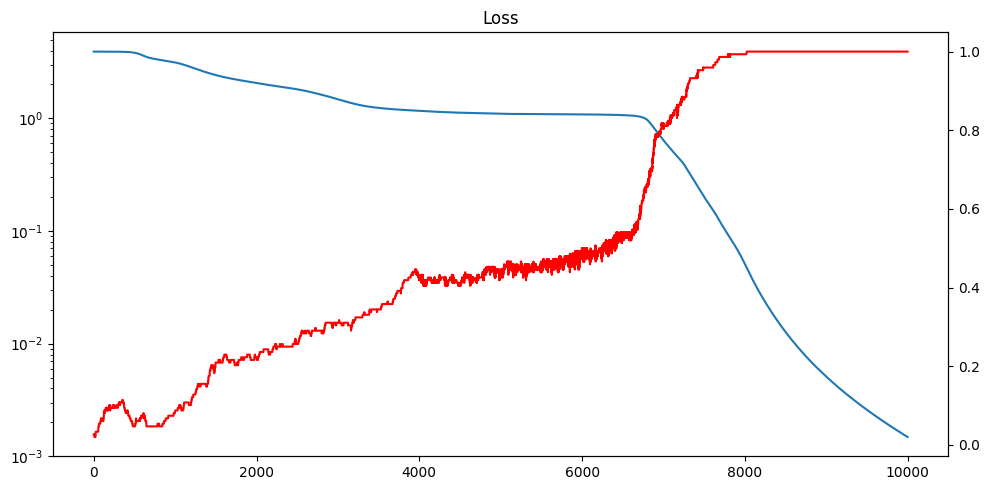

Changed G to 0.6148454546928406 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.1072637789766304e-05


100%|██████████| 10000/10000 [00:35<00:00, 284.25it/s]


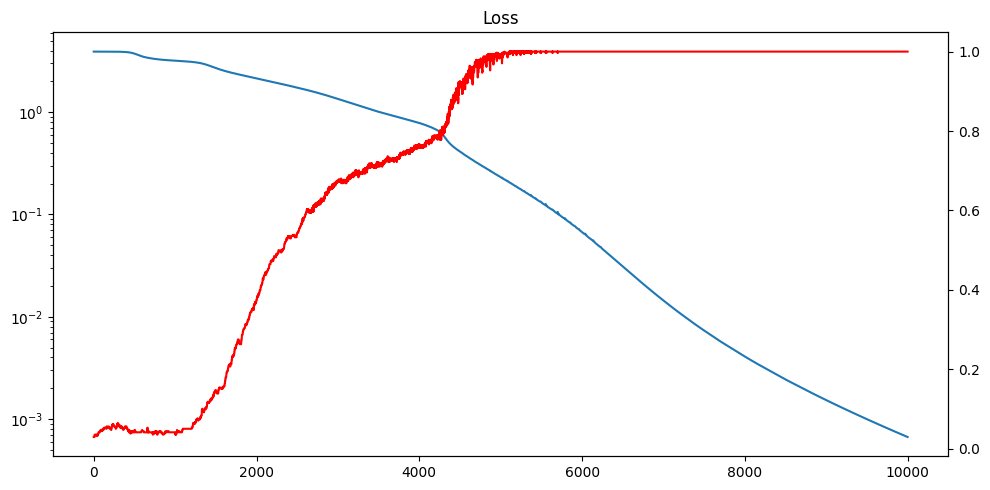

Changed G to 0.6161209940910339 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.1493737474665977e-05


100%|██████████| 10000/10000 [00:45<00:00, 217.86it/s]


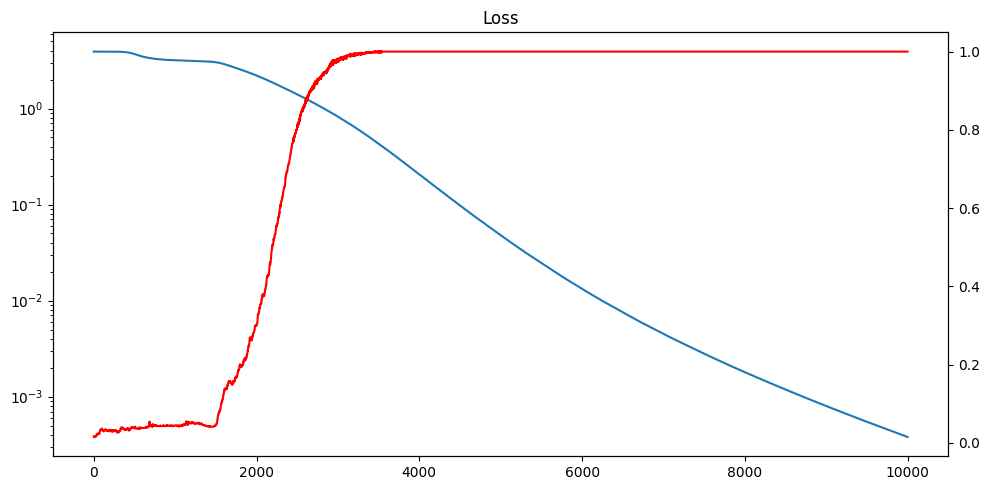

Changed G to 0.6173722147941589 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.0628975360305049e-05


100%|██████████| 10000/10000 [00:53<00:00, 185.82it/s]


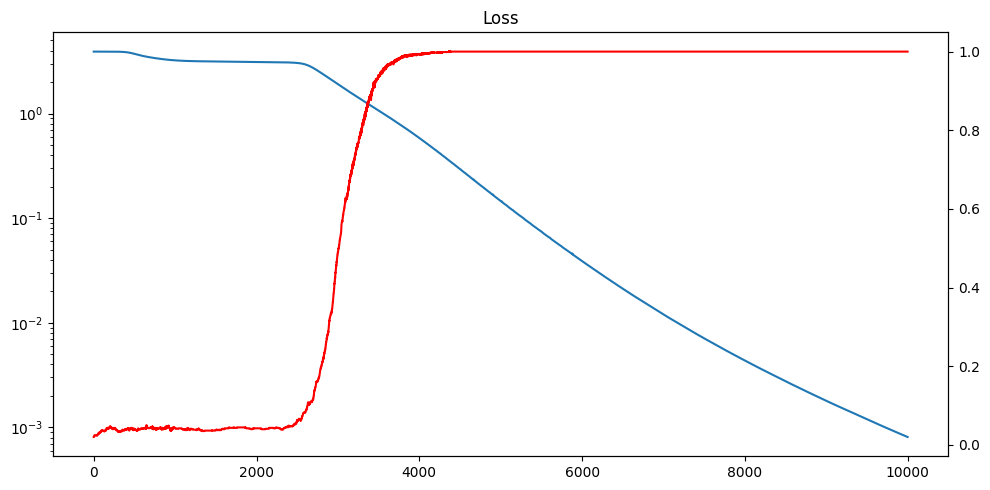

Changed G to 0.6185970902442932 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.0926520189968869e-05


100%|██████████| 10000/10000 [01:02<00:00, 159.88it/s]


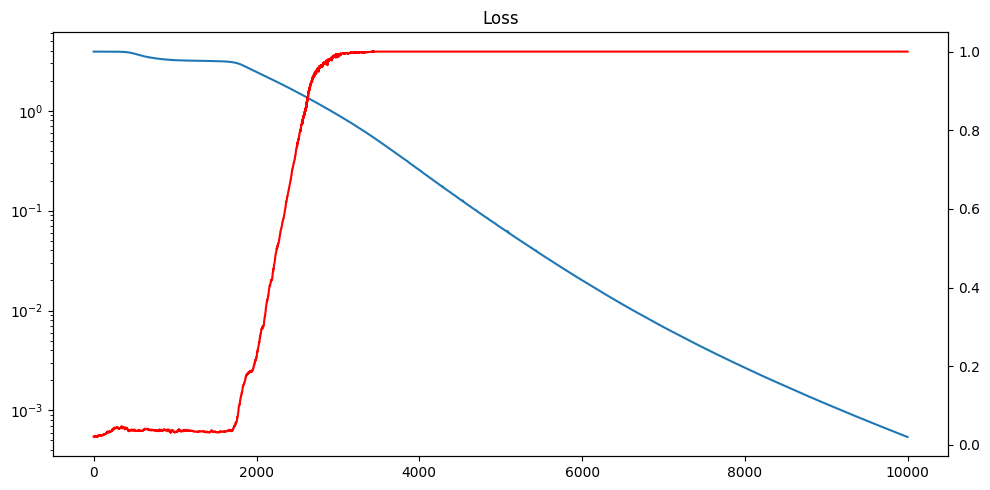

Changed G to 0.6193985342979431 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.046199304255424e-05


100%|██████████| 10000/10000 [01:07<00:00, 147.34it/s]


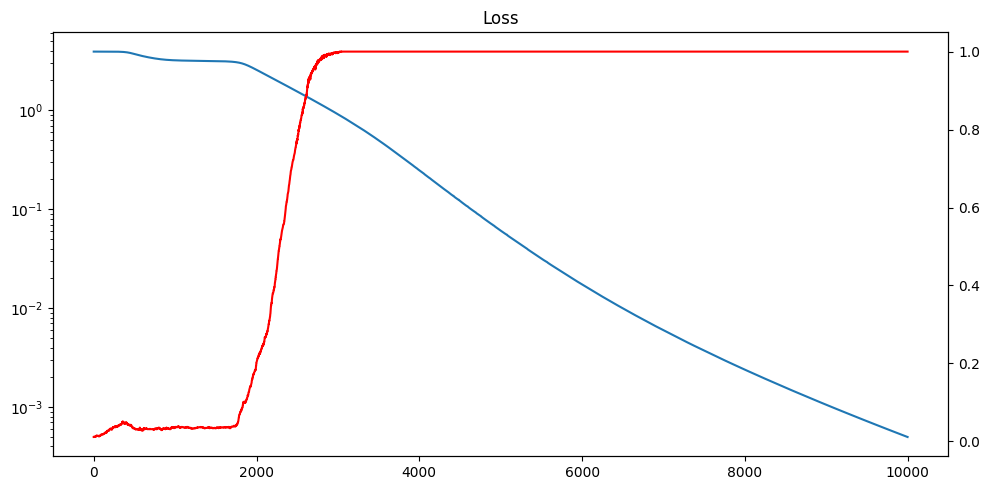

Changed G to 0.6205777525901794 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.0158340046473313e-05


100%|██████████| 10000/10000 [01:14<00:00, 133.60it/s]


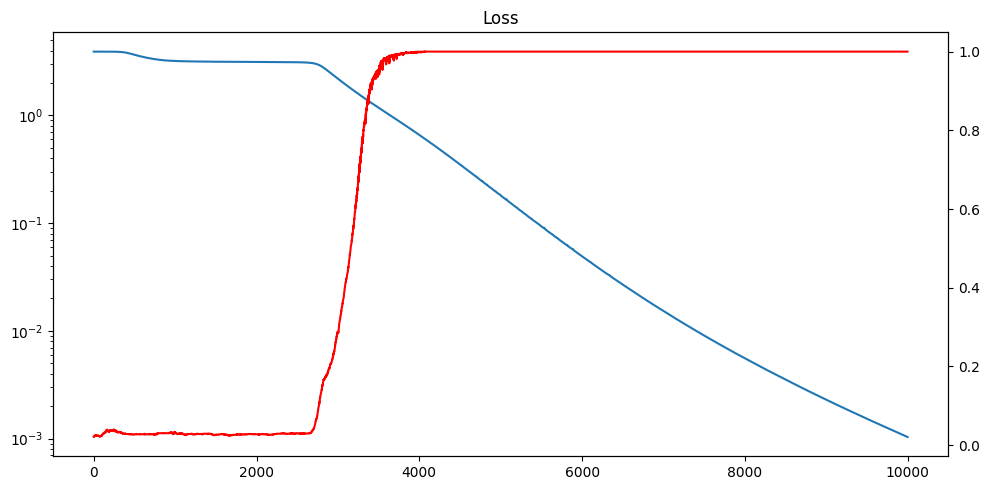

Changed G to 0.6217294335365295 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.0519166607991792e-05


100%|██████████| 10000/10000 [01:19<00:00, 126.28it/s]


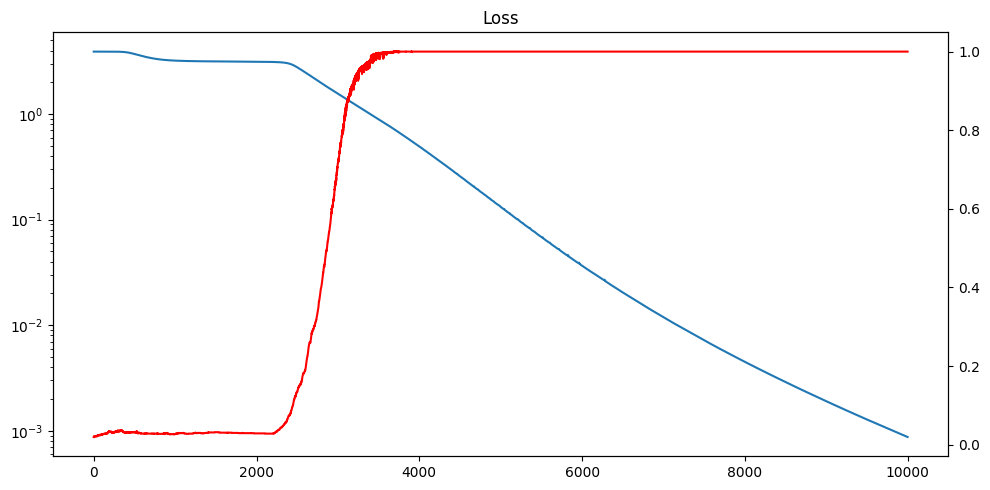

Changed G to 0.6228541135787964 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 1.0356722668802831e-05


100%|██████████| 10000/10000 [01:27<00:00, 114.63it/s]


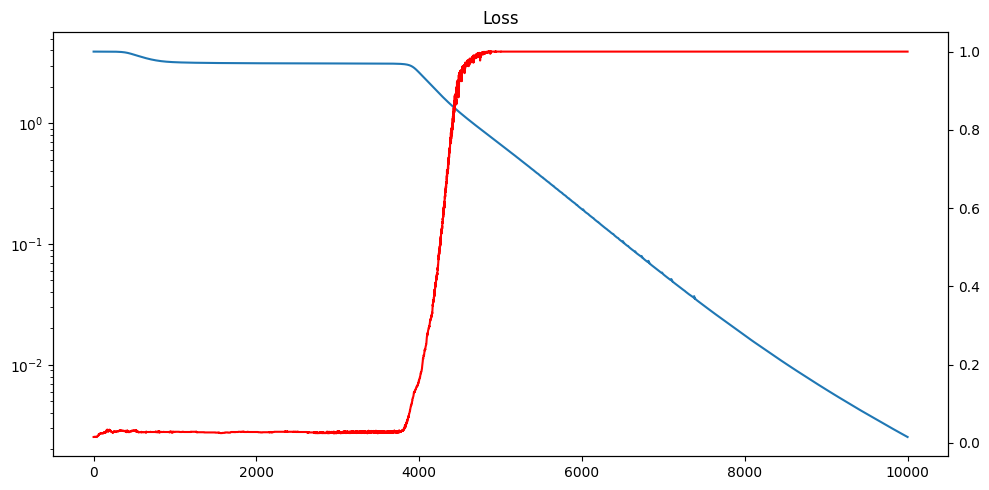

Changed G to 0.6239524483680725 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 8.187104867829476e-06


100%|██████████| 10000/10000 [01:30<00:00, 110.58it/s]


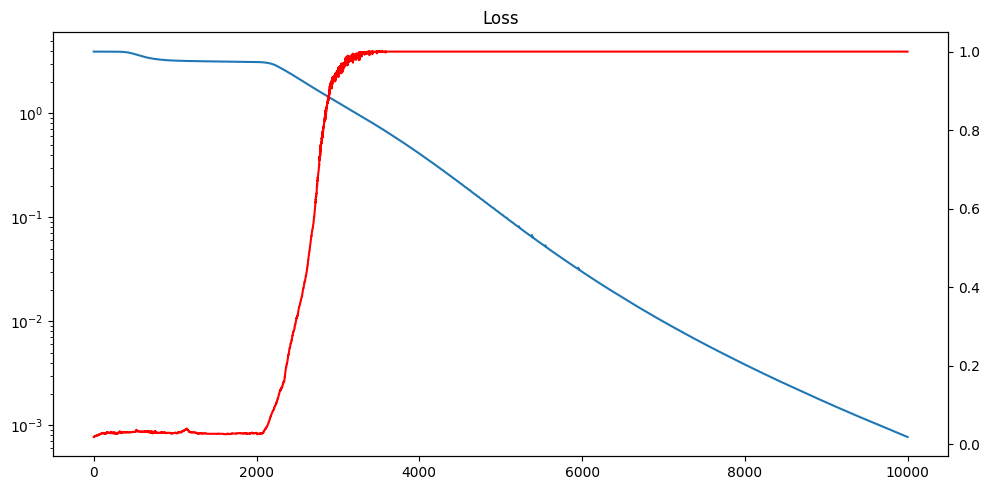

In [5]:

X_l = []
y_l = []
C_l = []
loc_y_l = []
hidden_l = []
W_model_l = []
W_corr_l = []
for max_move in np.linspace(1, C.length_corridors[0]//2+1, 10).astype(int):
    C.max_move = max_move

    X, y, corridor, loc_X, loc_y, action_taken, hidden_states, loss_l, accuracy_l, outputs, hidden_l, final_weights, initial_weights = run_sim(C)

    X_np = X.cpu().detach().numpy()
    y_np = y.cpu().detach().numpy()
    X_l.append(X_np)
    y_l.append(y_np)
    C_l.append(deepcopy(C))
    loc_y_l.append(loc_y)
    W_model_l.append(reduce(np.matmul, [W.cpu().numpy().T for W in final_weights.values()]).T)
    hidden_l.append(hidden_states[-1].detach().cpu().numpy())
    Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
    Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
    W_corr_l.append(Sigma31@np.linalg.pinv(Sigma11))

    indices = np.lexsort((loc_y, corridor))
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.plot(loss_l)
    ax.set_yscale('log')
    ax.twinx().plot(accuracy_l, 'r')
    ax.set_title("Loss")
    plt.tight_layout()
    plt.show()


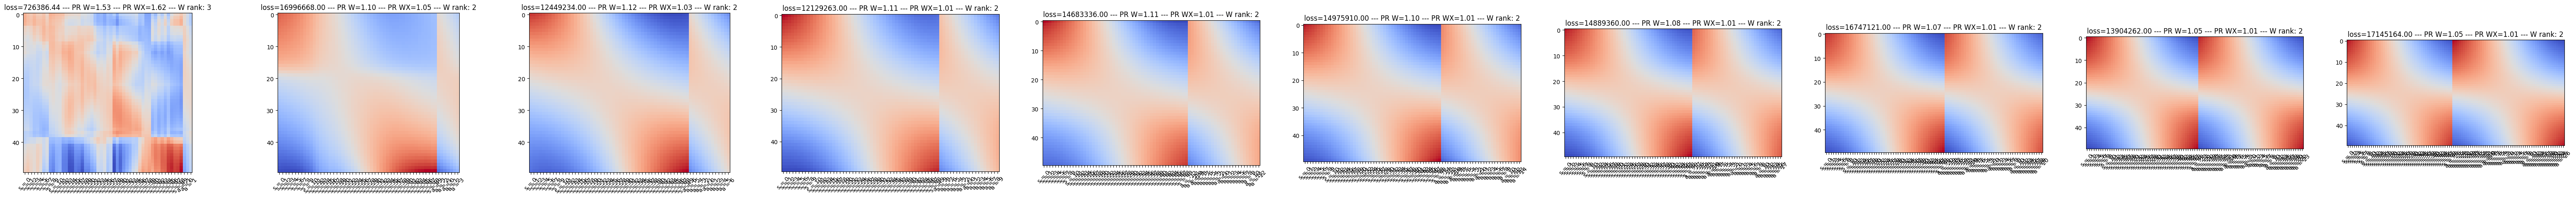

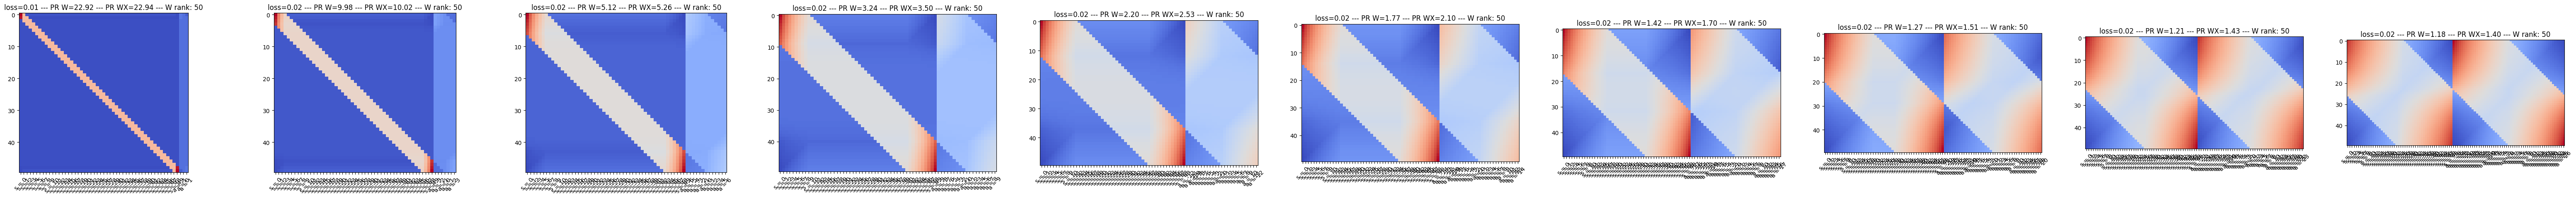

In [6]:
for W_l in [W_model_l, W_corr_l]:
    fig, axs = plt.subplots(1, len(X_l), figsize=(8*len(X_l),5))
    for X_np, y_np, W, C, ax in zip(X_l, y_l, W_l, C_l, axs):
        ax.imshow(W, cmap='coolwarm')
        lamb = PCA().fit(X_np@W.T).explained_variance_
        PRWX = lamb.sum() ** 2 / (lamb ** 2).sum()
        lamb = PCA().fit(W).explained_variance_
        PR = lamb.sum() ** 2 / (lamb ** 2).sum()
        ax.set_title(f'loss={((((X_np@W.T)- y_np))**2).mean():.2f} --- PR W={PR:.2f} --- PR WX={PRWX:.2f} --- W rank: {np.linalg.matrix_rank(W, tol=np.sqrt(lamb[0])*(1/W.shape[0]))}')
        ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
        ax.grid(False)

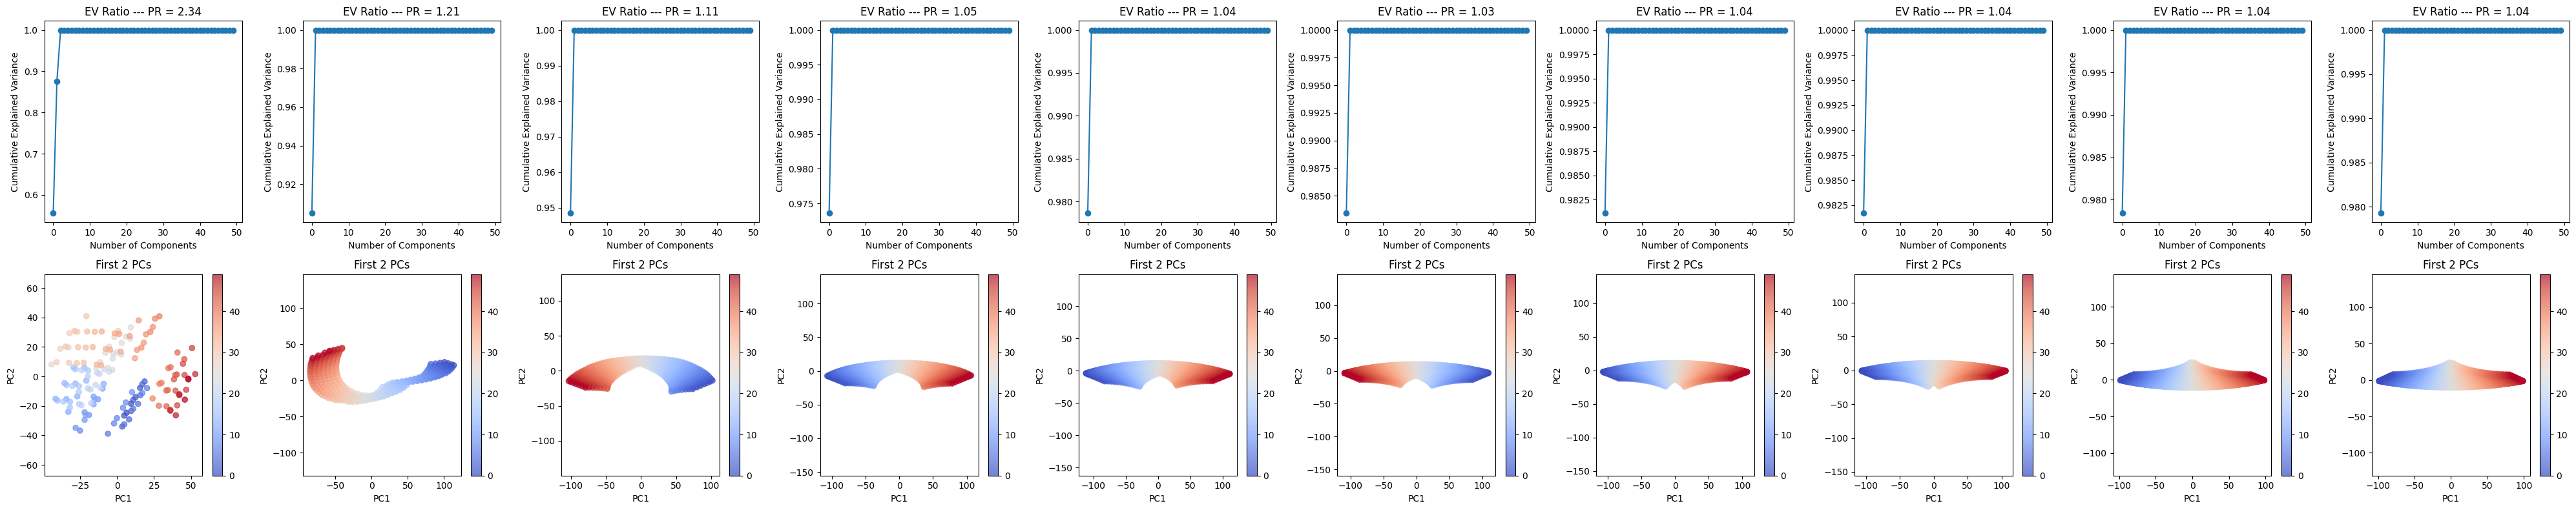

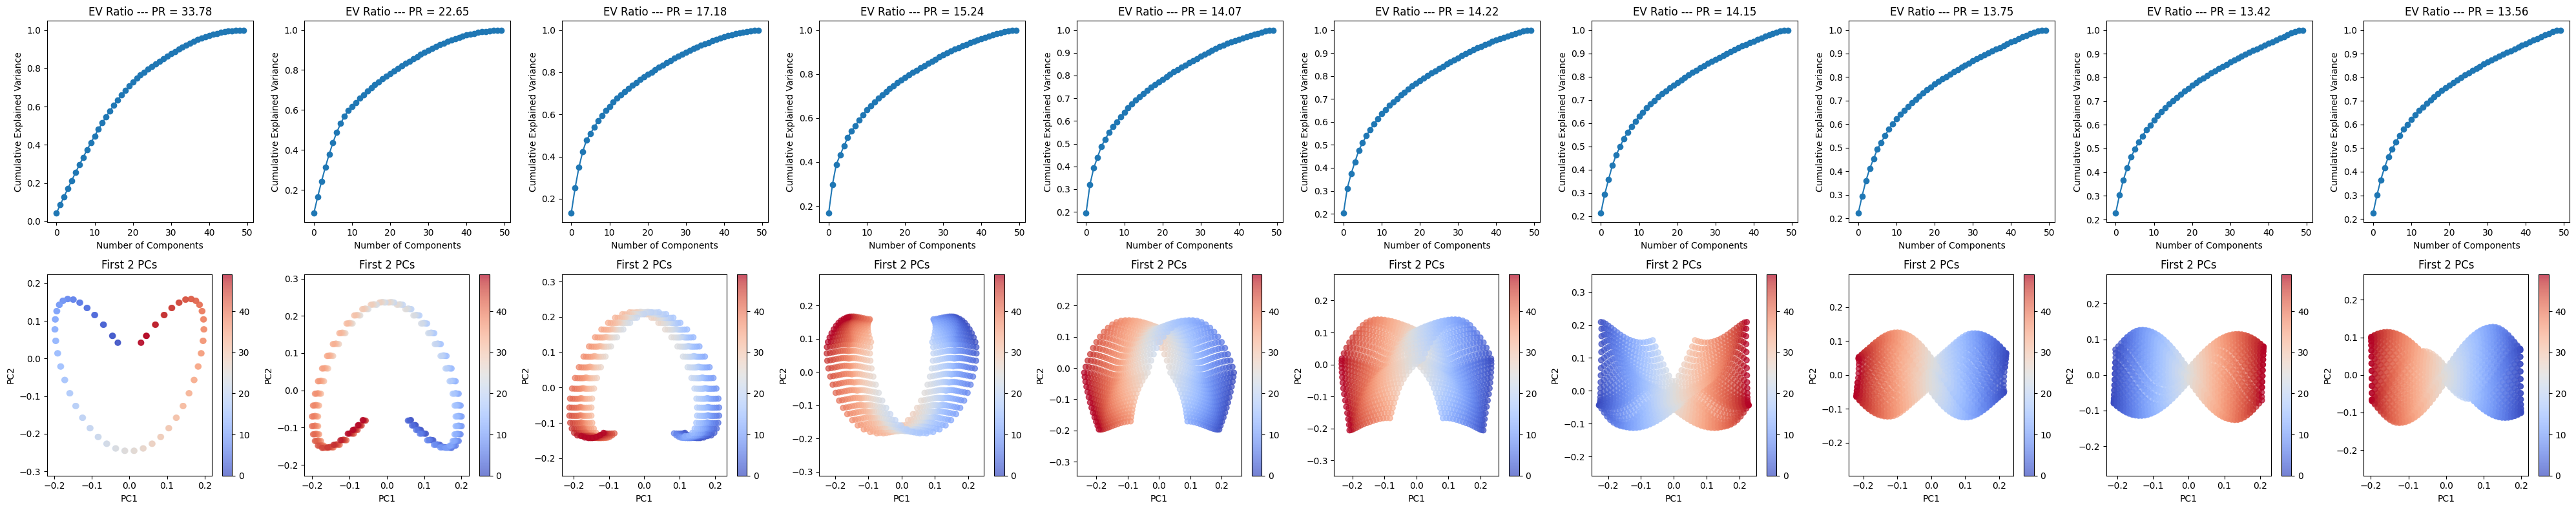

In [7]:
# Create figure with subplots for each W matrix
# Create figure with subplots for each W matrix
for W_l in [W_model_l, W_corr_l]:
    fig, axs = plt.subplots(2, len(X_l), figsize=(4*len(X_l), 8))
    axs = axs.T
    for i, (X_np, y_np, W, C, loc_y) in enumerate(zip(X_l, y_l, W_l, C_l, loc_y_l)):
        A, B = factorize_matrix(W, N=None)
        h_synthetic = X_np @ B.T
        
        # Fit PCA
        pca = PCA().fit(h_synthetic)
        X_reduced = pca.transform(h_synthetic)
        
        # Plot explained variance ratio
        axs[i,0].plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
        PR = pca.explained_variance_.sum()**2/(pca.explained_variance_**2).sum()
        axs[i,0].set_xlabel('Number of Components')
        axs[i,0].set_ylabel('Cumulative Explained Variance')
        axs[i,0].set_title(f'EV Ratio --- PR = {PR:.2f}')
        
        # Plot first two PCs colored by location
        s = axs[i,1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=loc_y, 
                            cmap='coolwarm', alpha=0.7)
        axs[i,1].set_xlabel('PC1')
        axs[i,1].set_ylabel('PC2')
        axs[i,1].set_title(f'First 2 PCs')
        fig.colorbar(s, ax=axs[i,1])
        axs[i,1].axis('equal')

    plt.tight_layout()
    plt.show()